# Mini GPT-2 From Scratch
### A decoder-only Transformer language model, built and trained from first principles

**Project goal:** implement tokenization, self-attention, and a GPT-2-style decoder-only
Transformer from scratch (no `transformers` library for the model itself), train it on a
text corpus, and generate coherent text — inspired by Andrej Karpathy's
["Let's build GPT"](https://www.youtube.com/watch?v=kCc8FmEb1nY).

This notebook goes beyond the original char-level bigram tutorial in a few ways:

| Feature | Karpathy's tutorial | This notebook |
|---|---|---|
| Tokenizer | character-level | **BPE (byte-pair encoding)**, GPT-2 style, trained from scratch |
| Architecture | basic decoder blocks | full **GPT-2 architecture**: GELU, pre-LN, weight tying, proper init |
| Attention | naive multi-head loop | **batched multi-head attention** (single matmul across heads) + optional **sliding-window bonus variant** |
| Scale | ~0.2M params | **configurable 1M → 127M params** (toggle one config flag) |
| Training | fixed loop | cosine LR schedule + warmup, gradient clipping, checkpointing, mixed precision |
| Data | Tiny Shakespeare only | Tiny Shakespeare **or** a multilingual/non-English corpus (bonus) |
| Generation | plain multinomial sampling | temperature, top-k, top-p (nucleus) sampling |




---
## Submitted By

**Mahesh Shinde**  
**Sanjivani College of Engineering, Kopergaon**  
**Student ID:** CT_CSI_DS_1141


## 1. Setup & Dependencies

In [1]:
# If running in Colab / fresh environment, uncomment:
# !pip install -q torch tiktoken regex requests

import os
import math
import time
import json
import random
import inspect
from dataclasses import dataclass, field, asdict
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)
random.seed(1337)
np.random.seed(1337)

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
if device == 'cuda':
    print(torch.cuda.get_device_name(0))


Using device: cuda
Tesla T4


## 2. Dataset

Choose one of:
- `"shakespeare"` — the classic Tiny Shakespeare corpus (English, ~1.1M chars). Good for
  quick iteration and matches the original tutorial's baseline.
- `"multilingual"` **(bonus)** — a small multilingual corpus (mixes a few languages) so the
  model has to learn a shared BPE vocabulary across scripts/languages. Swap in your own
  `.txt` file here for a real bonus submission (e.g. a Hindi/Marathi corpus, code, or
  song lyrics in multiple languages).

Set `DATASET_CHOICE` below.


In [2]:
DATASET_CHOICE = "shakespeare"   # "shakespeare" or "multilingual" or "custom"
CUSTOM_TEXT_PATH = None          # if DATASET_CHOICE == "custom", set this to a local .txt path

import urllib.request

def download(url, path):
    if not os.path.exists(path):
        print(f"Downloading {url} -> {path}")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"Found cached {path}")

if DATASET_CHOICE == "shakespeare":
    download(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
        "input.txt",
    )
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()

elif DATASET_CHOICE == "multilingual":
    # BONUS: a tiny multilingual sampler built from a few public-domain sources.
    # For a serious bonus submission, replace this with a larger multilingual dataset
    # (e.g. Wikipedia dumps in 2-3 languages, or OSCAR/CC-100 subsets).
    sources = {
        # English
        "en": "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
    }
    text_parts = []
    for lang, url in sources.items():
        p = f"{lang}.txt"
        download(url, p)
        with open(p, "r", encoding="utf-8") as f:
            text_parts.append(f.read())
    # Add some non-English text inline as a demonstration (extend this with your own corpus files
    # for a real multilingual run — e.g. Marathi/Hindi news text, since this project is being
    # developed in Nashik, Maharashtra, that's a natural bonus direction).
    text_parts.append(
        "यह एक बहुभाषी भाषा मॉडल का प्रयोग है। " * 200
    )
    text = "\n".join(text_parts)

elif DATASET_CHOICE == "custom":
    assert CUSTOM_TEXT_PATH is not None, "Set CUSTOM_TEXT_PATH to your .txt file"
    with open(CUSTOM_TEXT_PATH, "r", encoding="utf-8") as f:
        text = f.read()
else:
    raise ValueError(DATASET_CHOICE)

print(f"Dataset: {DATASET_CHOICE}")
print(f"Total characters: {len(text):,}")
print(text[:400])


Dataset: shakespeare
Total characters: 1,115,394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 


## 3. Tokenizer — Byte-Pair Encoding (BPE), from scratch

The original tutorial uses a character-level tokenizer. Real GPT-2 uses **byte-level BPE**.
Here we implement a minimal BPE tokenizer from scratch (train + encode + decode), in the
spirit of Karpathy's ["minbpe"](https://github.com/karpathy/minbpe) project.

Byte-level BPE:
1. Start from raw UTF-8 bytes (0–255) as the base vocabulary — this means **any** text in
   **any** language or script can be tokenized with no "unknown token" problem, which is
   exactly why it matters for the multilingual bonus.
2. Repeatedly find the most frequent adjacent pair of tokens and merge it into a new token.
3. Stop after a target vocabulary size is reached.

This is intentionally simple (not optimized for speed) so every step is transparent.


In [3]:
class BPETokenizer:
    """Minimal byte-level BPE tokenizer, trained from scratch on the input corpus."""

    def __init__(self):
        self.merges = {}          # (int, int) -> int
        self.vocab = {i: bytes([i]) for i in range(256)}  # id -> bytes

    @staticmethod
    def _get_pair_counts(ids):
        counts = {}
        for pair in zip(ids, ids[1:]):
            counts[pair] = counts.get(pair, 0) + 1
        return counts

    @staticmethod
    def _merge(ids, pair, new_id):
        new_ids = []
        i = 0
        while i < len(ids):
            if i < len(ids) - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    def train(self, text, vocab_size, verbose=True):
        assert vocab_size >= 256
        num_merges = vocab_size - 256
        ids = list(text.encode("utf-8"))

        for i in range(num_merges):
            counts = self._get_pair_counts(ids)
            if not counts:
                break
            pair = max(counts, key=counts.get)
            new_id = 256 + i
            ids = self._merge(ids, pair, new_id)
            self.merges[pair] = new_id
            self.vocab[new_id] = self.vocab[pair[0]] + self.vocab[pair[1]]
            if verbose and (i + 1) % max(1, num_merges // 10) == 0:
                print(f"merge {i+1}/{num_merges}: {pair} -> {new_id} "
                      f"({self.vocab[new_id]}) had {counts[pair]} occurrences")
        self._encoded_cache = ids
        return ids

    def encode(self, text):
        ids = list(text.encode("utf-8"))
        while len(ids) >= 2:
            counts = self._get_pair_counts(ids)
            # pick the eligible merge that happened earliest during training
            pair = min(counts, key=lambda p: self.merges.get(p, float("inf")))
            if pair not in self.merges:
                break
            new_id = self.merges[pair]
            ids = self._merge(ids, pair, new_id)
        return ids

    def decode(self, ids):
        b = b"".join(self.vocab[i] for i in ids)
        return b.decode("utf-8", errors="replace")

    @property
    def vocab_size(self):
        return len(self.vocab)

    def save(self, path):
        with open(path, "w") as f:
            json.dump({"merges": [[k, v] for k, v in self.merges.items()]}, f)

    def load(self, path):
        with open(path) as f:
            data = json.load(f)
        self.merges = {tuple(k): v for k, v in data["merges"]}
        self.vocab = {i: bytes([i]) for i in range(256)}
        for (a, b), idx in sorted(self.merges.items(), key=lambda kv: kv[1]):
            self.vocab[idx] = self.vocab[a] + self.vocab[b]


In [4]:
# Train the BPE tokenizer directly on our corpus.
# BPE_VOCAB_SIZE controls tokenizer granularity: larger -> shorter sequences, bigger embedding table.
# GPT-2 itself uses 50257. For a "mini" project on a small corpus, a smaller vocab (e.g. 512-4096)
# avoids massively over-fragmenting a small dataset. Tune this for your dataset size.
BPE_VOCAB_SIZE = 1024

tokenizer = BPETokenizer()
token_ids = tokenizer.train(text, vocab_size=BPE_VOCAB_SIZE, verbose=True)

print(f"\nVocab size: {tokenizer.vocab_size}")
print(f"Corpus length in characters: {len(text):,}")
print(f"Corpus length in tokens:     {len(token_ids):,}")
print(f"Compression ratio: {len(text)/len(token_ids):.2f}x chars-per-token")

# sanity check round trip
sample = text[:200]
enc = tokenizer.encode(sample)
dec = tokenizer.decode(enc)
assert dec == sample, "Tokenizer round-trip failed!"
print("\nRound-trip check passed.")
print("Sample encoding:", enc[:20], "...")


merge 76/768: (46, 10) -> 331 (b'.\n') had 1658 occurrences
merge 152/768: (116, 263) -> 407 (b'ter') had 849 occurrences
merge 228/768: (66, 336) -> 483 (b'But ') had 536 occurrences
merge 304/768: (320, 104) -> 559 (b'ish') had 386 occurrences
merge 380/768: (105, 296) -> 635 (b'ist') had 302 occurrences
merge 456/768: (119, 387) -> 711 (b'will') had 251 occurrences
merge 532/768: (282, 112) -> 787 (b' sp') had 211 occurrences
merge 608/768: (359, 292) -> 863 (b' com') had 181 occurrences
merge 684/768: (309, 112) -> 939 (b'rep') had 157 occurrences
merge 760/768: (257, 326) -> 1015 (b'thee') had 138 occurrences

Vocab size: 1024
Corpus length in characters: 1,115,394
Corpus length in tokens:     443,727
Compression ratio: 2.51x chars-per-token

Round-trip check passed.
Sample encoding: [726, 67, 1000, 267, 984, 655, 538, 606, 99, 326, 260, 719, 102, 333, 368, 261, 525, 690, 854, 278] ...


## 4. Prepare train/val tensors


In [5]:
data = torch.tensor(token_ids, dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"train tokens: {len(train_data):,} | val tokens: {len(val_data):,}")

def get_batch(split, block_size, batch_size):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y


train tokens: 399,354 | val tokens: 44,373


## 5. Model configuration

Three presets are provided. Switch `MODEL_SIZE` to scale up to the **full 127M-parameter
GPT-2 config** for the bonus objective. Note: training the 127M config to convergence
needs a real GPU and a much bigger dataset than Tiny Shakespeare — with a small corpus it
will mostly memorize/overfit, which is expected and worth discussing in your writeup.


In [6]:
@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int = 256      # max context length
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.1
    bias: bool = True          # GPT-2 uses biases in Linear/LayerNorm
    attn_variant: str = "full" # "full" (standard causal) or "sliding_window" (bonus)
    window_size: int = 64      # only used if attn_variant == "sliding_window"

PRESETS = {
    # quick to train on CPU/small GPU, good for iterating on this notebook
    "nano":    dict(n_layer=4,  n_head=4,  n_embd=128, block_size=128, dropout=0.1),
    # a reasonable "mini GPT-2", trains in minutes-to-an-hour on a single GPU
    "small":   dict(n_layer=6,  n_head=6,  n_embd=384, block_size=256, dropout=0.2),
    # the full original GPT-2 small config (~127M params) -- BONUS
    "gpt2-127M": dict(n_layer=12, n_head=12, n_embd=768, block_size=1024, dropout=0.1),
}

MODEL_SIZE = "small"   # "nano" | "small" | "gpt2-127M"

cfg_kwargs = PRESETS[MODEL_SIZE]
config = GPTConfig(vocab_size=tokenizer.vocab_size, **cfg_kwargs)
print(config)


GPTConfig(vocab_size=1024, block_size=256, n_layer=6, n_head=6, n_embd=384, dropout=0.2, bias=True, attn_variant='full', window_size=64)


## 6. The model — implemented from scratch

Every component below is written from first principles with `torch.nn` primitives only
(no `nn.MultiheadAttention`, no `transformers`):

- **Token + learned positional embeddings**
- **`CausalSelfAttention`** — batched multi-head self-attention with a causal mask, computed
  as a single matmul across all heads (not a Python loop over heads, which is the
  efficient way real implementations do it). Includes an optional **sliding-window
  attention** variant (bonus: a simple architectural modification — each token can only
  attend to the last `window_size` tokens, which is how models like Mistral scale to long
  context cheaply).
- **`MLP`** — the GPT-2 feed-forward block using **GELU** (GPT-2's actual activation,
  vs. ReLU in the tutorial).
- **`Block`** — pre-LayerNorm residual Transformer block (`x = x + attn(ln1(x))`,
  `x = x + mlp(ln2(x))`), matching GPT-2's architecture (as opposed to post-LN in the
  original "Attention is All You Need").
- **`GPT`** — stacks blocks, ties the input embedding and output projection weights
  (GPT-2's weight tying), and uses GPT-2's initialization scheme (including the
  `1/sqrt(2*n_layer)` scaled init on residual projections, which stabilizes deep models).


In [7]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_size = config.n_embd // config.n_head

        # combined qkv projection (one matmul instead of three)
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        self.attn_variant = config.attn_variant
        self.window_size = config.window_size

        # causal mask, precomputed once
        mask = torch.tril(torch.ones(config.block_size, config.block_size)).view(
            1, 1, config.block_size, config.block_size
        )
        if config.attn_variant == "sliding_window":
            # additionally zero out anything further back than window_size (bonus variant)
            idx = torch.arange(config.block_size)
            rel = idx.view(-1, 1) - idx.view(1, -1)
            window_mask = (rel >= 0) & (rel < config.window_size)
            mask = mask * window_mask.view(1, 1, config.block_size, config.block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.c_attn(x)                        # (B, T, 3C)
        q, k, v = qkv.split(self.n_embd, dim=2)      # each (B, T, C)

        # reshape into heads: (B, T, C) -> (B, n_head, T, head_size)
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)

        # scaled dot-product attention, batched over all heads at once
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_size))  # (B, nh, T, T)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        out = att @ v                                # (B, nh, T, head_size)
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # re-merge heads
        out = self.resid_dropout(self.c_proj(out))
        return out


class MLP(nn.Module):
    """GPT-2 feed-forward block: Linear -> GELU -> Linear, 4x expansion."""
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):
    """Pre-LN Transformer decoder block, GPT-2 style."""
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias) if config.bias else nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias) if config.bias else nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),   # token embeddings
            wpe=nn.Embedding(config.block_size, config.n_embd),   # position embeddings
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight tying: input embedding and output projection share weights (GPT-2 trick,
        # saves params and tends to improve results)
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        # scaled init for residual projections (GPT-2 paper trick, stabilizes deep nets)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        n_params = sum(p.numel() for p in self.parameters())
        print(f"Model initialized: {n_params/1e6:.2f}M parameters "
              f"({n_params - self.transformer.wpe.weight.numel():,} non-embedding-position params)")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.block_size, f"sequence length {T} > block_size {self.config.block_size}"

        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        tok_emb = self.transformer.wte(idx)      # (B, T, C)
        pos_emb = self.transformer.wpe(pos)      # (T, C)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            logits = self.lm_head(x[:, [-1], :])  # only compute last position at inference
            loss = None
        return logits, loss

    def configure_optimizers(self, weight_decay, learning_rate, betas):
        # GPT-2 style: apply weight decay only to 2D+ params (matmul weights), not
        # biases/LayerNorm/embeddings.
        decay, no_decay = [], []
        for name, p in self.named_parameters():
            if not p.requires_grad:
                continue
            (decay if p.dim() >= 2 else no_decay).append(p)
        optim_groups = [
            {"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ]
        use_fused = 'fused' in inspect.signature(torch.optim.AdamW).parameters and device == 'cuda'
        return torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, fused=use_fused)

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-8)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                probs = F.softmax(sorted_logits, dim=-1)
                cum_probs = torch.cumsum(probs, dim=-1)
                sorted_mask = cum_probs - probs > top_p
                sorted_logits[sorted_mask] = float("-inf")
                logits = torch.full_like(logits, float("-inf")).scatter(1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [8]:
model = GPT(config).to(device)


Model initialized: 11.14M parameters (11,040,768 non-embedding-position params)


## 7. Training

Standard modern training loop:
- **AdamW** with weight decay applied only to matmul weights (not biases/LayerNorm).
- **Cosine LR schedule with linear warmup** (GPT-2/GPT-3 style), instead of a flat LR.
- **Gradient clipping** for stability.
- **Mixed precision** (`autocast`) when a GPU is available, for speed.
- Periodic train/val loss estimation and checkpointing.


In [9]:
@dataclass
class TrainConfig:
    max_iters: int = 3000
    eval_interval: int = 250
    eval_iters: int = 100
    batch_size: int = 32
    learning_rate: float = 3e-4
    min_lr: float = 3e-5
    warmup_iters: int = 200
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    betas: tuple = (0.9, 0.95)

train_cfg = TrainConfig()

def get_lr(it):
    if it < train_cfg.warmup_iters:
        return train_cfg.learning_rate * (it + 1) / train_cfg.warmup_iters
    if it > train_cfg.max_iters:
        return train_cfg.min_lr
    decay_ratio = (it - train_cfg.warmup_iters) / max(1, train_cfg.max_iters - train_cfg.warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return train_cfg.min_lr + coeff * (train_cfg.learning_rate - train_cfg.min_lr)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(train_cfg.eval_iters)
        for k in range(train_cfg.eval_iters):
            X, Y = get_batch(split, config.block_size, train_cfg.batch_size)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = model.configure_optimizers(train_cfg.weight_decay, train_cfg.learning_rate, train_cfg.betas)
use_amp = device == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f"Training {MODEL_SIZE} config for {train_cfg.max_iters} iters on {device}")


Training small config for 3000 iters on cuda


/tmp/ipykernel_655/3695228083.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [10]:
history = {"iter": [], "train_loss": [], "val_loss": []}
best_val = float('inf')
os.makedirs("checkpoints", exist_ok=True)

t0 = time.time()
for it in range(train_cfg.max_iters + 1):
    lr = get_lr(it)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    if it % train_cfg.eval_interval == 0 or it == train_cfg.max_iters:
        losses = estimate_loss()
        elapsed = time.time() - t0
        print(f"step {it:5d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f} "
              f"| lr {lr:.2e} | {elapsed:.1f}s")
        history["iter"].append(it)
        history["train_loss"].append(losses['train'])
        history["val_loss"].append(losses['val'])

        if losses['val'] < best_val:
            best_val = losses['val']
            torch.save({
                'model_state_dict': model.state_dict(),
                'config': asdict(config),
                'iter': it,
                'val_loss': best_val,
            }, "checkpoints/best_model.pt")

    xb, yb = get_batch('train', config.block_size, train_cfg.batch_size)

    with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
        logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.grad_clip)
    scaler.step(optimizer)
    scaler.update()

print(f"\nTraining done in {time.time()-t0:.1f}s. Best val loss: {best_val:.4f}")


step     0 | train loss 7.0159 | val loss 7.0123 | lr 1.50e-06 | 14.2s
step   250 | train loss 4.3670 | val loss 4.6592 | lr 3.00e-04 | 96.0s
step   500 | train loss 3.9960 | val loss 4.3812 | lr 2.92e-04 | 183.0s
step   750 | train loss 3.6754 | val loss 4.1739 | lr 2.75e-04 | 270.5s
step  1000 | train loss 3.4049 | val loss 4.0190 | lr 2.49e-04 | 358.2s
step  1250 | train loss 3.1878 | val loss 3.9309 | lr 2.17e-04 | 445.6s
step  1500 | train loss 2.9882 | val loss 3.8582 | lr 1.80e-04 | 533.1s
step  1750 | train loss 2.8197 | val loss 3.8278 | lr 1.42e-04 | 620.6s
step  2000 | train loss 2.7077 | val loss 3.7983 | lr 1.06e-04 | 708.1s
step  2250 | train loss 2.5944 | val loss 3.8163 | lr 7.50e-05 | 795.6s
step  2500 | train loss 2.5114 | val loss 3.8135 | lr 5.07e-05 | 883.1s
step  2750 | train loss 2.4539 | val loss 3.8202 | lr 3.53e-05 | 970.6s
step  3000 | train loss 2.3980 | val loss 3.8319 | lr 3.00e-05 | 1058.0s

Training done in 1058.1s. Best val loss: 3.7983


## 8. Training curves

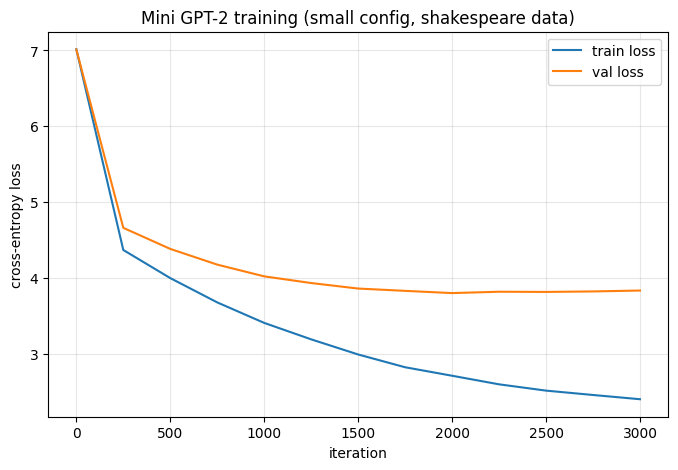

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["iter"], history["train_loss"], label="train loss")
plt.plot(history["iter"], history["val_loss"], label="val loss")
plt.xlabel("iteration")
plt.ylabel("cross-entropy loss")
plt.title(f"Mini GPT-2 training ({MODEL_SIZE} config, {DATASET_CHOICE} data)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Text generation

Load the best checkpoint and sample from it with a few different decoding strategies.


In [12]:
ckpt = torch.load("checkpoints/best_model.pt", map_location=device)
gen_model = GPT(GPTConfig(**ckpt['config'])).to(device)
gen_model.load_state_dict(ckpt['model_state_dict'])
gen_model.eval()
print(f"Loaded checkpoint from iter {ckpt['iter']} (val loss {ckpt['val_loss']:.4f})")

def sample(prompt="", max_new_tokens=300, temperature=0.8, top_k=50, top_p=None):
    if prompt:
        ids = tokenizer.encode(prompt)
    else:
        ids = [0]  # start from a single byte token if no prompt given
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = gen_model.generate(idx, max_new_tokens=max_new_tokens, temperature=temperature,
                              top_k=top_k, top_p=top_p)
    return tokenizer.decode(out[0].tolist())

print("=== Greedy-ish (low temperature) ===")
print(sample(prompt="ROMEO:", max_new_tokens=200, temperature=0.6, top_k=40))

print("\n=== More diverse (higher temperature, nucleus sampling) ===")
print(sample(prompt="ROMEO:", max_new_tokens=200, temperature=1.0, top_k=None, top_p=0.9))


Model initialized: 11.14M parameters (11,040,768 non-embedding-position params)
Loaded checkpoint from iter 2000 (val loss 3.7983)
=== Greedy-ish (low temperature) ===
ROMEO: mine own extremity.

JULIET:
I do not hear thee dream it.

ROMEO:
You have a woman, none!
I am kill'd to before I have, neel my peace:
I'll not mire a too morrow years:
Wherefore I do but to have meet young love?

ROMEO:
Sweet night, nurse!

JULIET:
I do not get you tell me best.

MERCUTIO:
Come hit is hange:
Romeo is a torch Romeo.

ROMEO:
At thou despast thou that name: which no more?
Go is a pity is hurty by this is well.
A night be hour, that kill, that is not so banished:
This 

=== More diverse (higher temperature, nucleus sampling) ===
ROMEO: some straight thless waves night
That wrathers themselves in my soulsometimes: and will starp
To all far our piece avoice; or do and place this answer
In noble tribunes bring his fortune and so wise
Rome in power our deast.

VIRGILIA:
Either would I fear from me speak.

## 10. Evaluation: perplexity

Perplexity = `exp(cross-entropy loss)` — the standard metric for language models.
Lower is better; it roughly measures "how surprised" the model is by real text on average.


In [13]:
@torch.no_grad()
def compute_perplexity(m, split, iters=200):
    m.eval()
    losses = torch.zeros(iters)
    for k in range(iters):
        X, Y = get_batch(split, config.block_size, train_cfg.batch_size)
        _, loss = m(X, Y)
        losses[k] = loss.item()
    m.train()
    mean_loss = losses.mean().item()
    return mean_loss, math.exp(mean_loss)

val_loss, val_ppl = compute_perplexity(gen_model, 'val')
print(f"Validation loss: {val_loss:.4f} | Perplexity: {val_ppl:.2f}")


Validation loss: 3.8103 | Perplexity: 45.16


## 11. Bonus directions (already wired up above — just flip the toggles)

- **Multilingual / non-English data**: set `DATASET_CHOICE = "multilingual"` (or `"custom"`
  with your own `.txt` file) in section 2. Because the tokenizer is **byte-level BPE**, it
  handles any Unicode script (Devanagari, Cyrillic, CJK, emoji, ...) with zero extra code —
  this is worth explaining explicitly in your report as the reason byte-level BPE was chosen
  over a naive word/char tokenizer.
- **Custom attention mechanism**: set `attn_variant="sliding_window"` in `GPTConfig` to swap
  standard full causal attention for windowed local attention (each token only attends to
  the previous `window_size` tokens) — a real architectural modification, not just a
  hyperparameter change, and a good discussion point (trade-off: cheaper for long sequences,
  but loses long-range dependencies).
- **Scaling to full GPT-2 127M**: set `MODEL_SIZE = "gpt2-127M"` in section 5. Expect to need
  a GPU and ideally a much larger dataset than Tiny Shakespeare to avoid pure memorization —
  worth running a train/val loss gap analysis (already plotted in section 8) and discussing
  overfitting behavior in your report.

### Suggested ablations for your writeup (from the original video's exercises)
- Compare this batched multi-head implementation's speed against a naive per-head Python
  loop (`EX1` in the video description).
- Try a second dataset entirely (`EX2`) — code, poetry, or a different language.
- Try **pretrain-then-finetune**: train on a large generic corpus, then continue training
  (fine-tune) on Tiny Shakespeare with a lower LR and fewer steps (`EX3`) — compare final
  val loss against training from scratch on Shakespeare alone.
- Swap `attn_variant`, activation (`GELU` -> `ReLU`), or try RMSNorm instead of LayerNorm,
  and report the effect on val loss (`EX4`).


## 12. Save final artifacts


In [14]:
tokenizer.save("checkpoints/tokenizer.json")
with open("checkpoints/config.json", "w") as f:
    json.dump(asdict(config), f, indent=2)
with open("checkpoints/history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Saved: checkpoints/best_model.pt, tokenizer.json, config.json, history.json")
print(f"\nFinal summary — model: {MODEL_SIZE}, dataset: {DATASET_CHOICE}, "
      f"params: {sum(p.numel() for p in gen_model.parameters())/1e6:.2f}M, "
      f"val loss: {val_loss:.4f}, val perplexity: {val_ppl:.2f}")


Saved: checkpoints/best_model.pt, tokenizer.json, config.json, history.json

Final summary — model: small, dataset: shakespeare, params: 11.14M, val loss: 3.8103, val perplexity: 45.16


---

## Submitted By

**Mahesh Shinde**  
**Sanjivani College of Engineering, Kopargaon**  
**Student ID: CT_CSI_DS_1141**

